In [33]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
import os
import json
from urllib.parse import urlencode
from urllib.request import Request, urlopen

In [34]:
#define state

class BMIState(TypedDict):
    weight: float
    height: float
    bmi: float
    api_bmi: float
    bmi_category: str
    bmi_api_status: str

In [35]:
def calculate_bmi(state: BMIState) -> BMIState:
    state['bmi'] = state['weight'] / (state['height'] ** 2)
    return (state)

In [36]:
def fetch_bmi_from_api(state: BMIState) -> BMIState:
    """Fetch BMI from API Ninjas if API key is present; otherwise use local BMI."""
    api_key = os.getenv("API_NINJAS_KEY", "").strip()

    # Fallback to local BMI when key is missing
    if not api_key:
        state["api_bmi"] = state["bmi"]
        state["bmi_api_status"] = "API key missing; used local BMI"
        return state

    params = urlencode({"weight": state["weight"], "height": state["height"]})
    url = f"https://api.api-ninjas.com/v1/bmi?{params}"
    req = Request(url, headers={"X-Api-Key": api_key, "Accept": "application/json"})

    try:
        with urlopen(req, timeout=10) as response:
            payload = json.loads(response.read().decode("utf-8"))
            state["api_bmi"] = float(payload.get("bmi", state["bmi"]))
            state["bmi_api_status"] = "API success"
    except Exception as exc:
        state["api_bmi"] = state["bmi"]
        state["bmi_api_status"] = f"API failed; used local BMI ({type(exc).__name__})"

    return state


def classify_weight_status(state: BMIState) -> BMIState:
    bmi_value = state.get("api_bmi", state["bmi"])

    if bmi_value < 18.5:
        category = "Underweight"
    elif bmi_value < 25:
        category = "Normal weight"
    elif bmi_value < 30:
        category = "Overweight"
    else:
        category = "Obese"

    state["bmi_category"] = category
    return state

In [37]:
#define graph

graph = StateGraph(BMIState)
#add nodes
graph.add_node("calculate_bmi", calculate_bmi)
graph.add_node("fetch_bmi_api", fetch_bmi_from_api)
graph.add_node("classify_weight", classify_weight_status)

#add edges
graph.add_edge(START, "calculate_bmi")
graph.add_edge("calculate_bmi", "fetch_bmi_api")
graph.add_edge("fetch_bmi_api", "classify_weight")
graph.add_edge("classify_weight", END)

#compile graph
workflow = graph.compile()

In [38]:
#execute graph
initial_state = BMIState(
    weight=70,
    height=1.75,
    bmi=0,
    api_bmi=0,
    bmi_category="",
    bmi_api_status=""
)
final_state = workflow.invoke(initial_state)
print(final_state)

{'weight': 70, 'height': 1.75, 'bmi': 22.857142857142858, 'api_bmi': 22.857142857142858, 'bmi_category': 'Normal weight', 'bmi_api_status': 'API key missing; used local BMI'}


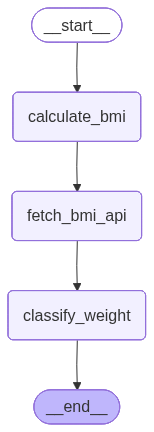

In [39]:
#view graph
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())